# Exploratory Data Analysis: Supermart Grocery Sales

This notebook explores the **Supermart Grocery Sales – Retail Analytics Dataset** to understand its structure, distributions, relationships, and potential insights before building a final project.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

## 1. Loading & Inspecting the Dataset

In [17]:
df = pd.read_csv('Supermart Grocery Sales - Retail Analytics Dataset.csv')
print(f'Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns')
df.head(10)

Dataset shape: 9994 rows × 11 columns


,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu
5,OD6,Adavan,Food Grains,Organic Staples,Dharmapuri,06-09-2015,West,2305,0.26,322.70,Tamil Nadu
6,OD7,Jonas,Fruits & Veggies,Fresh Vegetables,Trichy,06-09-2015,West,826,0.33,346.92,Tamil Nadu
7,OD8,Hafiz,Fruits & Veggies,Fresh Fruits,Ramanadhapuram,06-09-2015,West,1847,0.32,147.76,Tamil Nadu
8,OD9,Hafiz,Bakery,Biscuits,Tirunelveli,06-09-2015,West,791,0.23,181.93,Tamil Nadu
9,OD10,Krithika,Bakery,Cakes,Chennai,06-09-2015,West,1795,0.27,484.65,Tamil Nadu


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       9994 non-null   str    
 1   Customer Name  9994 non-null   str    
 2   Category       9994 non-null   str    
 3   Sub Category   9994 non-null   str    
 4   City           9994 non-null   str    
 5   Order Date     9994 non-null   str    
 6   Region         9994 non-null   str    
 7   Sales          9994 non-null   int64  
 8   Discount       9994 non-null   float64
 9   Profit         9994 non-null   float64
 10  State          9994 non-null   str    
dtypes: float64(2), int64(1), str(8)
memory usage: 859.0 KB


In [19]:
df.describe()

,Sales,Discount,Profit
count,9994.000000,9994.000000,9994.000000
mean,1496.596158,0.226817,374.937082
std,577.559036,0.074636,239.932881
min,500.000000,0.100000,25.250000
25%,1000.000000,0.160000,180.022500
50%,1498.000000,0.230000,320.780000
75%,1994.750000,0.290000,525.627500
max,2500.000000,0.350000,1120.950000


In [20]:
df.describe(include='object')

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,State
count,9994,9994,9994,9994,9994,9994,9994,9994
unique,9994,50,7,23,24,1236,5,1
top,OD1,Amrish,Snacks,Health Drinks,Kanyakumari,09-05-2017,West,Tamil Nadu
freq,1,227,1514,719,459,38,3203,9994


## 2. Data Cleaning & Missing Values

In [21]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

Total missing values: 0


In [22]:
print('Duplicate rows:', df.duplicated().sum())

Duplicate rows: 0


In [23]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='mixed', dayfirst=False)
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month_Name'] = df['Order Date'].dt.month_name()

print('Date range:', df['Order Date'].min(), 'to', df['Order Date'].max())
print('Years present:', sorted(df['Year'].unique()))

Date range: 2015-01-03 00:00:00 to 2018-12-30 00:00:00
Years present: [np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018)]


In [24]:
print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()}')

Unique values per column:
  Order ID: 9994
  Customer Name: 50
  Category: 7
  Sub Category: 23
  City: 24
  Order Date: 1236
  Region: 5
  Sales: 1989
  Discount: 26
  Profit: 8380
  State: 1
  Year: 4
  Month: 12
  Month_Name: 12


## 3. Distributions of Numerical Variables

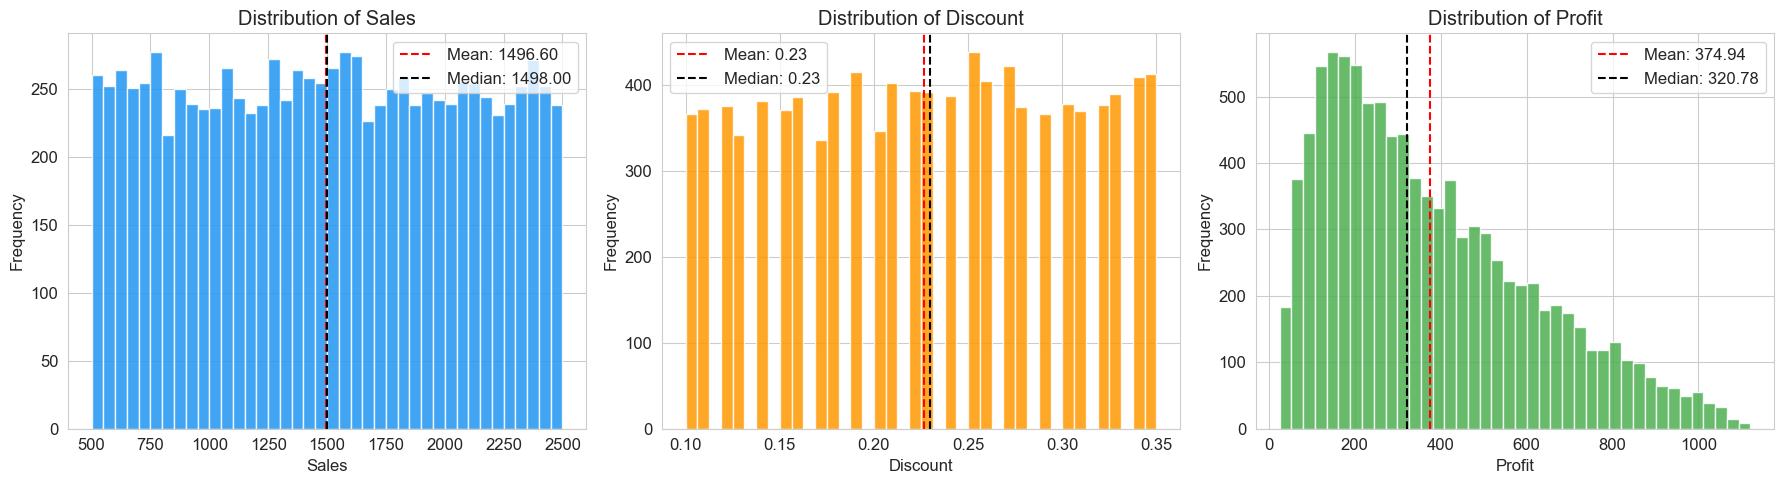

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ['Sales', 'Discount', 'Profit'], ['#2196F3', '#FF9800', '#4CAF50']):
    ax.hist(df[col], bins=40, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='black', linestyle='--', label=f'Median: {df[col].median():.2f}')
    ax.set_title(f'Distribution of {col}')
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.tight_layout()
plt.show()

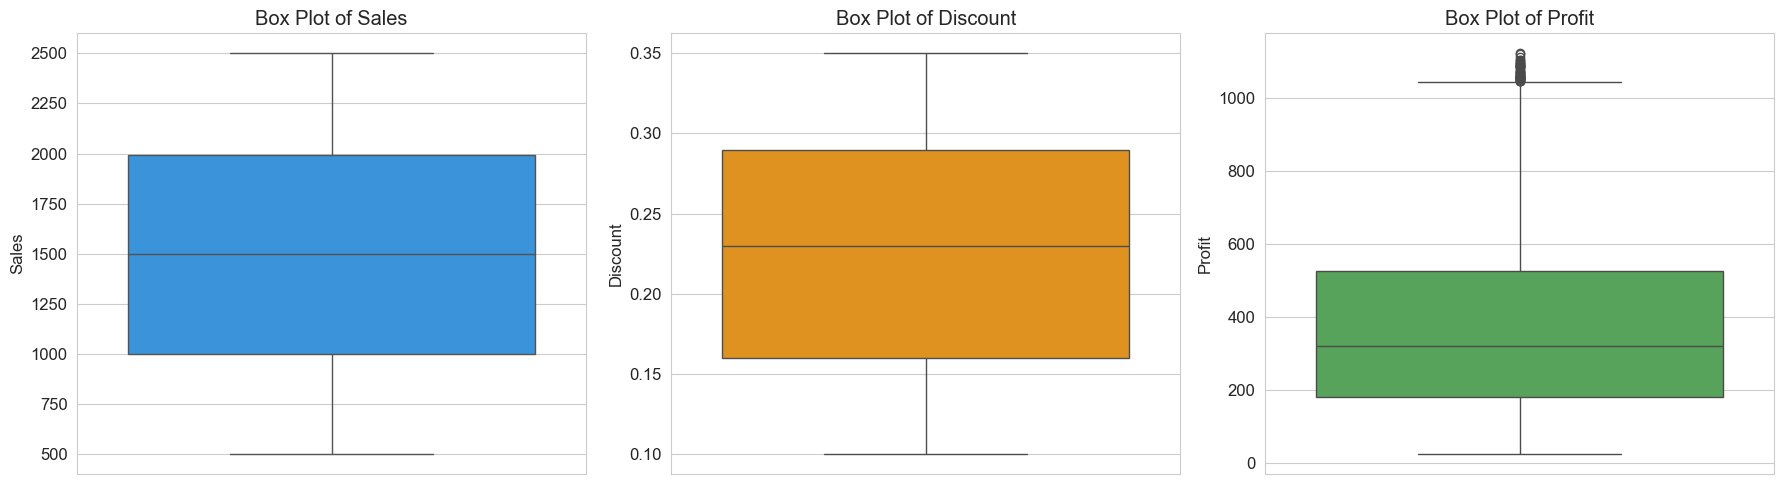

In [26]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, color in zip(axes, ['Sales', 'Discount', 'Profit'], ['#2196F3', '#FF9800', '#4CAF50']):
    sns.boxplot(y=df[col], ax=ax, color=color)
    ax.set_title(f'Box Plot of {col}')

plt.tight_layout()
plt.show()

### Checking for Outliers with IQR

In [27]:
for col in ['Sales', 'Discount', 'Profit']:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%) | Range [{lower:.2f}, {upper:.2f}]')

Sales: 0 outliers (0.0%) | Range [-492.12, 3486.88]
Discount: 0 outliers (0.0%) | Range [-0.03, 0.48]
Profit: 43 outliers (0.4%) | Range [-338.38, 1044.04]


## 4. Categorical Variable Analysis

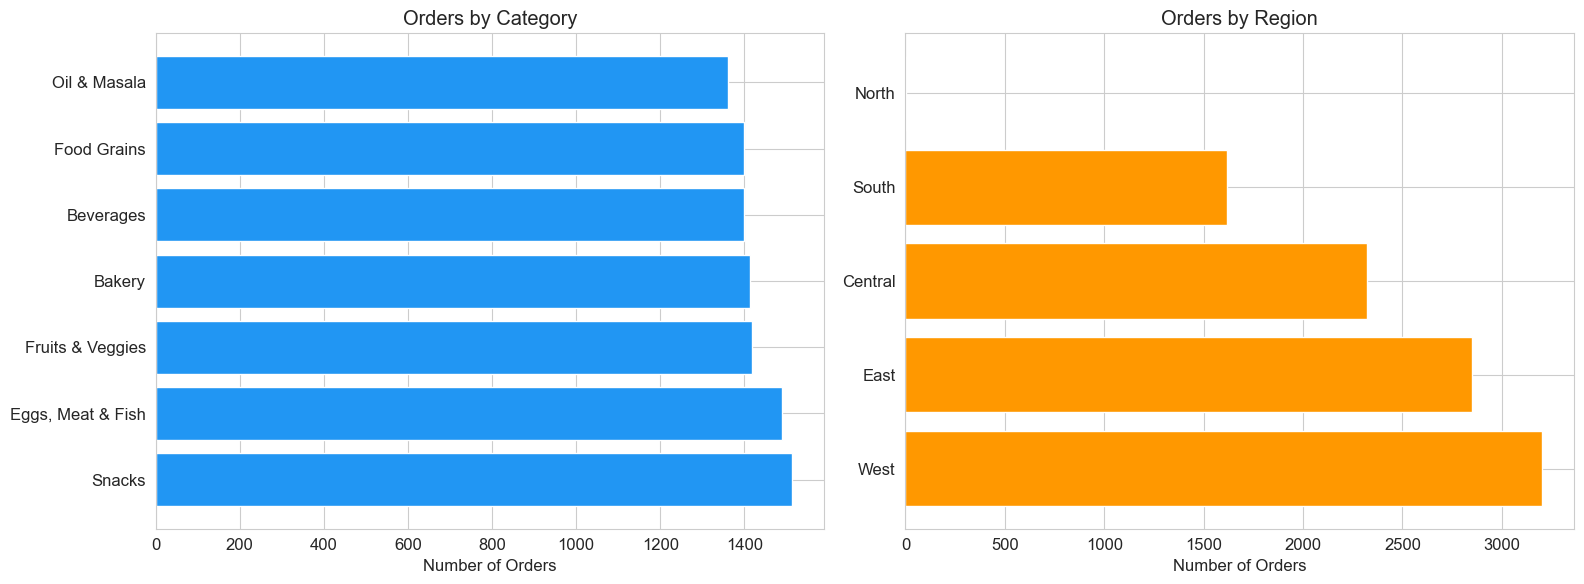

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cat_counts = df['Category'].value_counts()
axes[0].barh(cat_counts.index, cat_counts.values, color='#2196F3')
axes[0].set_title('Orders by Category')
axes[0].set_xlabel('Number of Orders')

region_counts = df['Region'].value_counts()
axes[1].barh(region_counts.index, region_counts.values, color='#FF9800')
axes[1].set_title('Orders by Region')
axes[1].set_xlabel('Number of Orders')

plt.tight_layout()
plt.show()

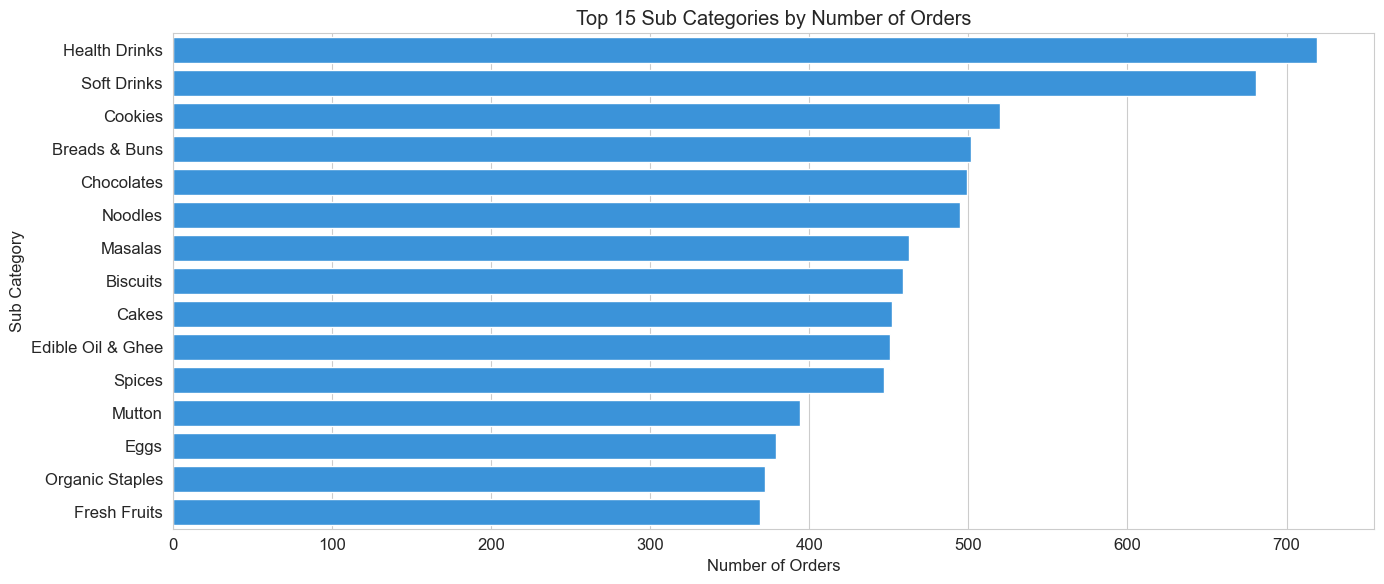

In [29]:
top_sub = df['Sub Category'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_sub.values, y=top_sub.index, color='#2196F3')
plt.title('Top 15 Sub Categories by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('Sub Category')
plt.tight_layout()
plt.show()

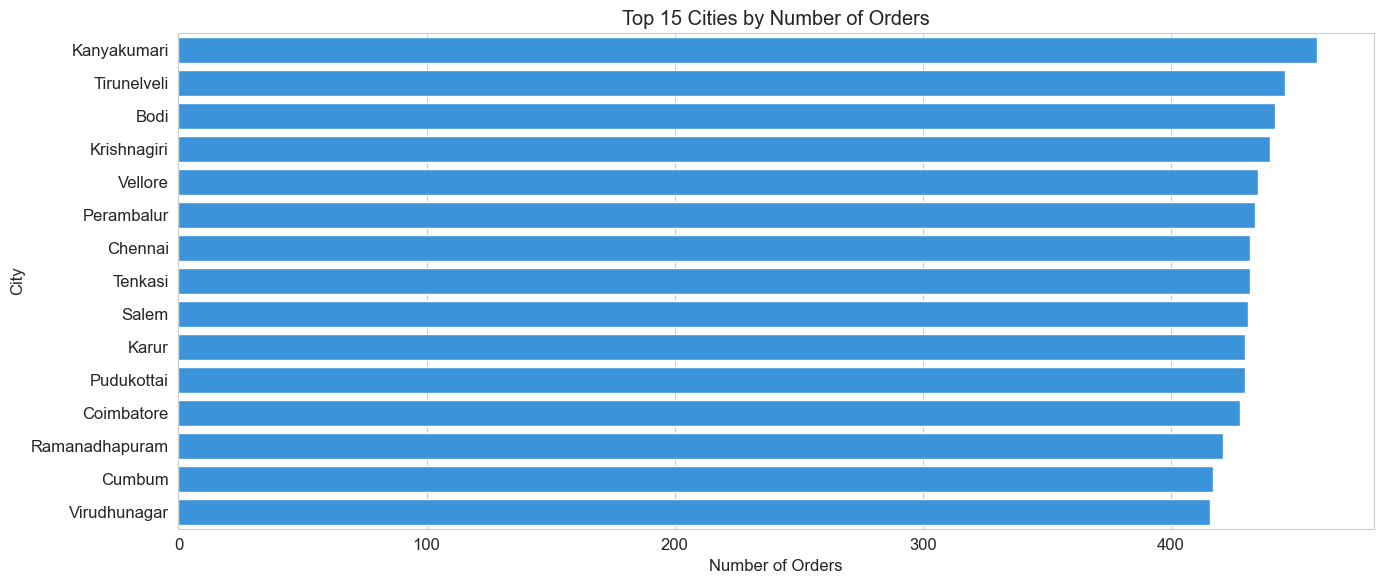

In [30]:
top_cities = df['City'].value_counts().head(15)

plt.figure(figsize=(14, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, color='#2196F3')
plt.title('Top 15 Cities by Number of Orders')
plt.xlabel('Number of Orders')
plt.ylabel('City')
plt.tight_layout()
plt.show()

## 5. Sales, Profit & Discount Analysis by Category

In [31]:
cat_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Order_Count=('Order ID', 'count'),
    Avg_Sales=('Sales', 'mean'),
    Avg_Profit=('Profit', 'mean')
).sort_values('Total_Sales', ascending=False)

cat_summary['Profit_Margin_%'] = (cat_summary['Total_Profit'] / cat_summary['Total_Sales'] * 100).round(2)
cat_summary

,Total_Sales,Total_Profit,Avg_Discount,Order_Count,Avg_Sales,Avg_Profit,Profit_Margin_%
Category,,,,,,,
"Eggs, Meat & Fish",2267401,567357.22,0.227792,1490,1521.745638,380.776658,25.02
Snacks,2237546,568178.85,0.222048,1514,1477.903567,375.283256,25.39
Food Grains,2115272,529162.64,0.228548,1398,1513.070100,378.514049,25.02
Bakery,2112281,528521.06,0.225428,1413,1494.891012,374.041798,25.02
Fruits & Veggies,2100727,530400.38,0.229295,1418,1481.471791,374.048223,25.25
Beverages,2085313,525605.76,0.230329,1400,1489.509286,375.432686,25.21
Oil & Masala,2038442,497895.29,0.224526,1361,1497.753123,365.830485,24.43


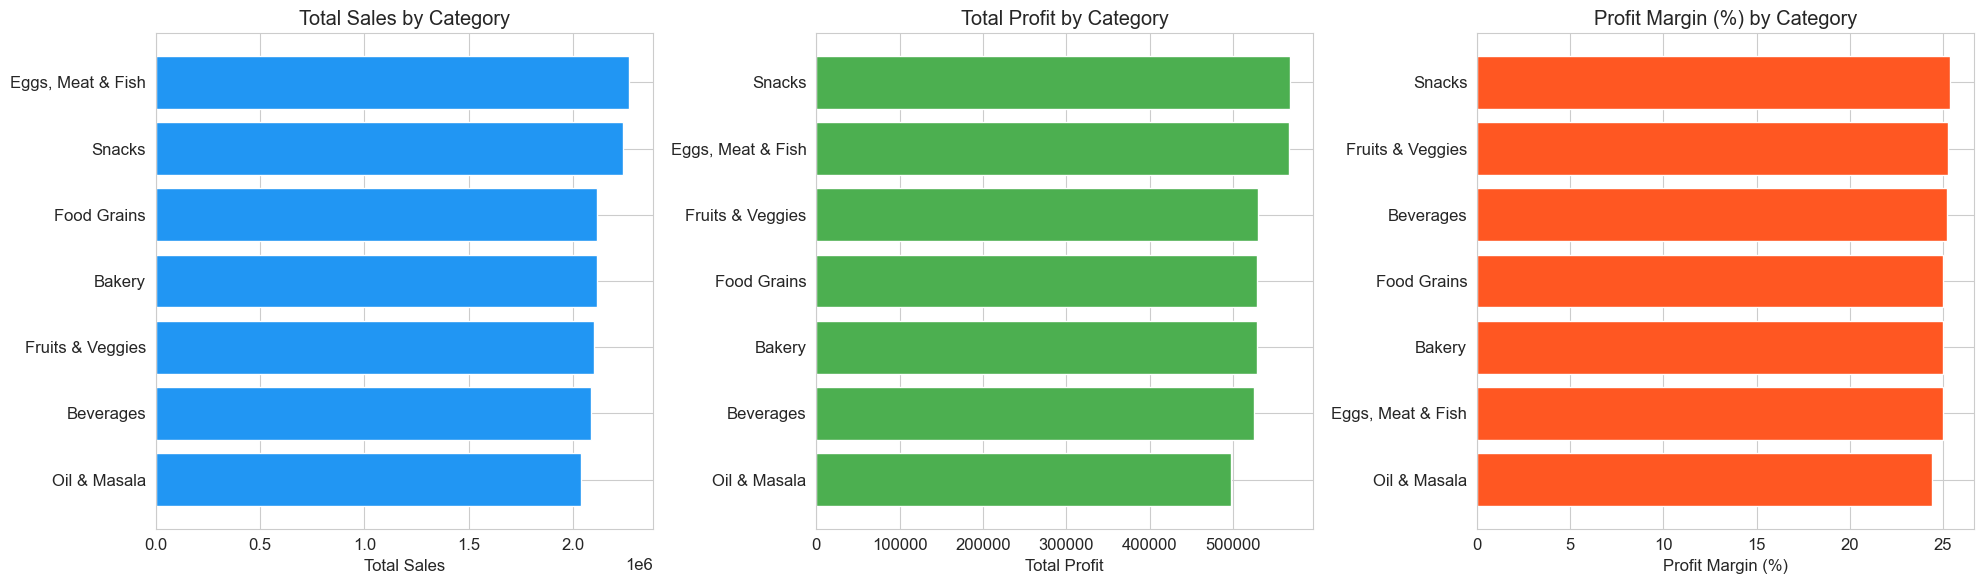

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

cat_summary_sorted = cat_summary.sort_values('Total_Sales', ascending=True)
axes[0].barh(cat_summary_sorted.index, cat_summary_sorted['Total_Sales'], color='#2196F3')
axes[0].set_title('Total Sales by Category')
axes[0].set_xlabel('Total Sales')

cat_summary_sorted = cat_summary.sort_values('Total_Profit', ascending=True)
axes[1].barh(cat_summary_sorted.index, cat_summary_sorted['Total_Profit'], color='#4CAF50')
axes[1].set_title('Total Profit by Category')
axes[1].set_xlabel('Total Profit')

cat_summary_sorted = cat_summary.sort_values('Profit_Margin_%', ascending=True)
axes[2].barh(cat_summary_sorted.index, cat_summary_sorted['Profit_Margin_%'], color='#FF5722')
axes[2].set_title('Profit Margin (%) by Category')
axes[2].set_xlabel('Profit Margin (%)')

plt.tight_layout()
plt.show()

## 6. Relationships Between Variables

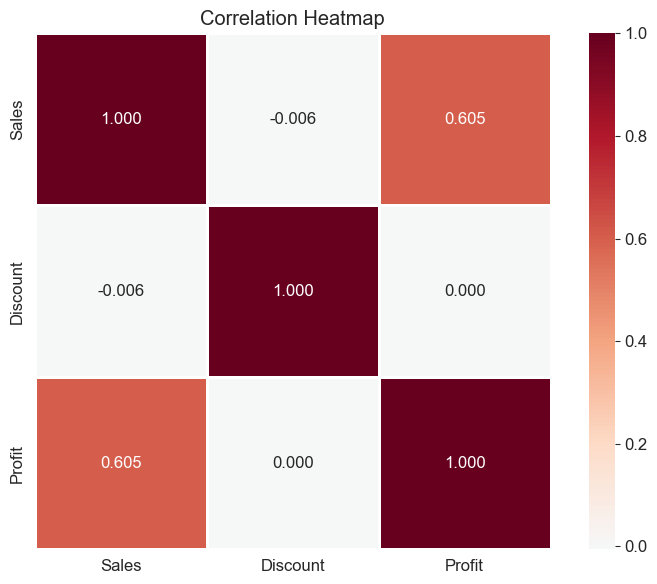

In [33]:
plt.figure(figsize=(8, 6))
correlation = df[['Sales', 'Discount', 'Profit']].corr()
sns.heatmap(correlation, annot=True, cmap='RdBu_r', center=0, fmt='.3f',
            linewidths=1, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

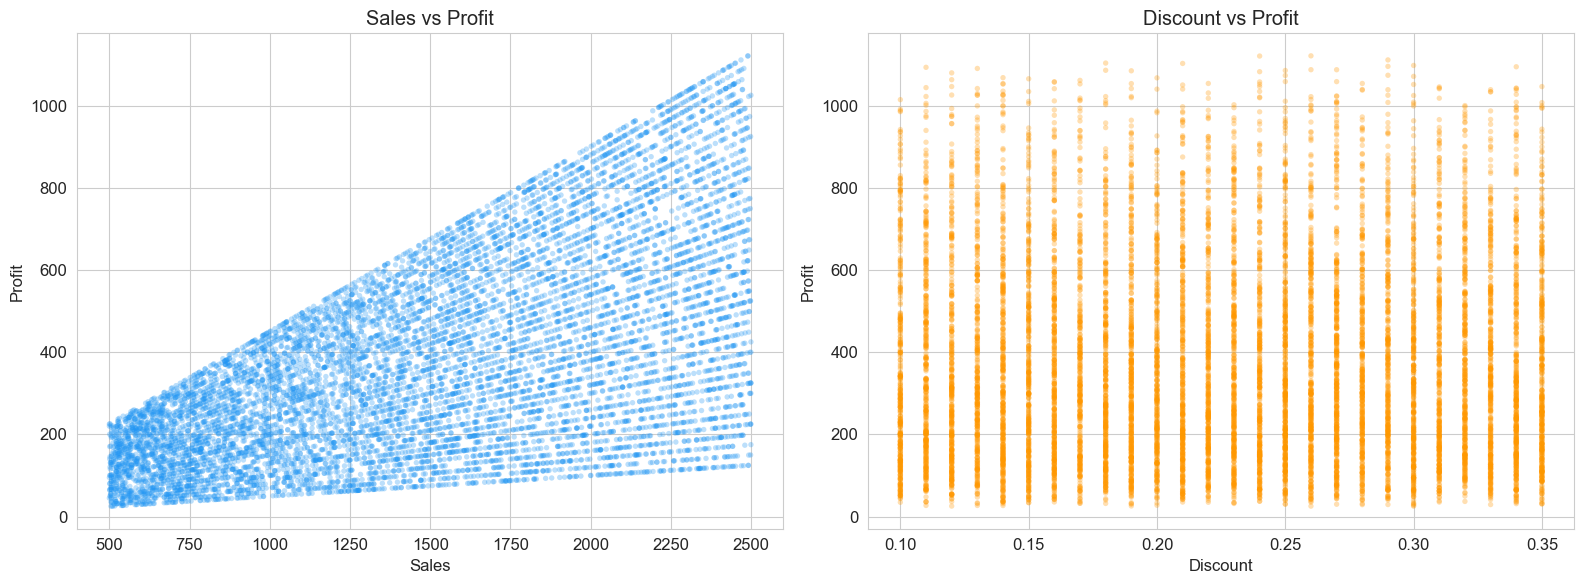

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].scatter(df['Sales'], df['Profit'], alpha=0.3, c='#2196F3', edgecolors='none', s=15)
axes[0].set_xlabel('Sales')
axes[0].set_ylabel('Profit')
axes[0].set_title('Sales vs Profit')

axes[1].scatter(df['Discount'], df['Profit'], alpha=0.3, c='#FF9800', edgecolors='none', s=15)
axes[1].set_xlabel('Discount')
axes[1].set_ylabel('Profit')
axes[1].set_title('Discount vs Profit')

plt.tight_layout()
plt.show()

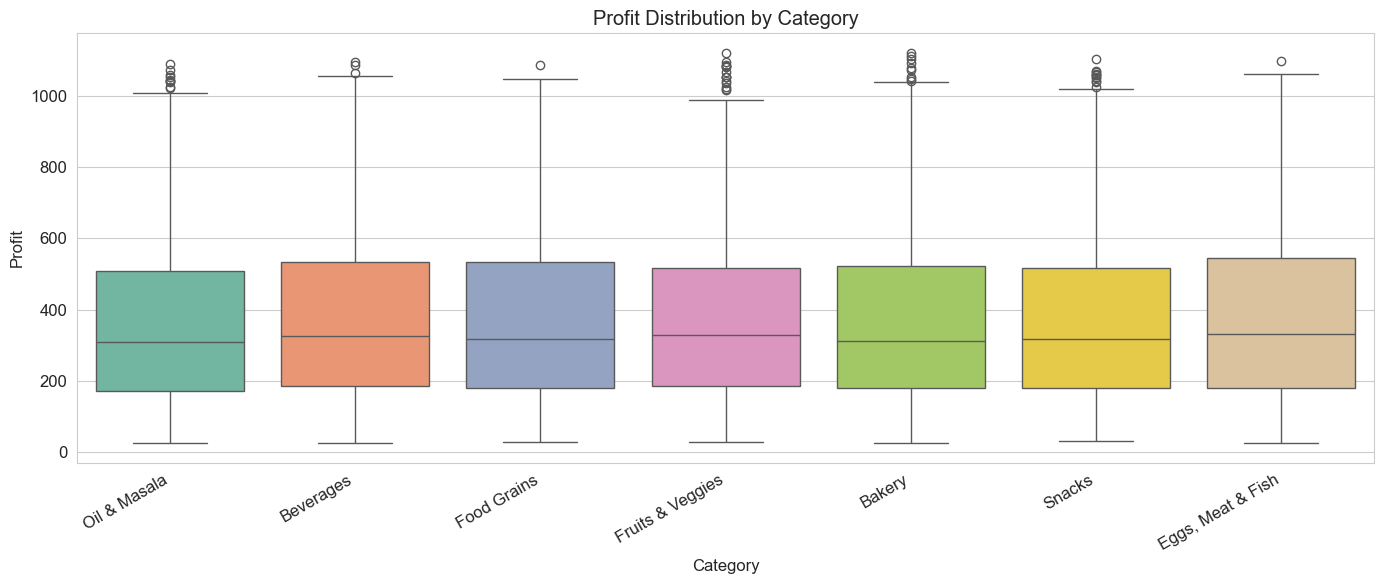

In [35]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df, x='Category', y='Profit', palette='Set2')
plt.xticks(rotation=30, ha='right')
plt.title('Profit Distribution by Category')
plt.tight_layout()
plt.show()

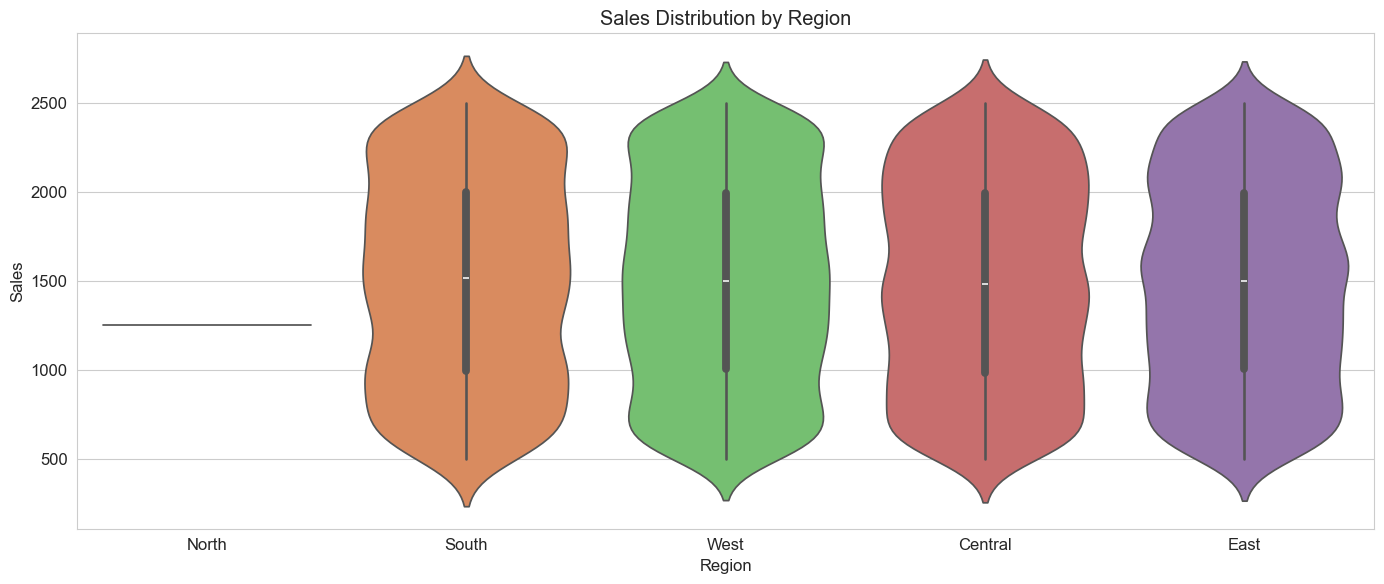

In [36]:
plt.figure(figsize=(14, 6))
sns.violinplot(data=df, x='Region', y='Sales', palette='muted', inner='box')
plt.title('Sales Distribution by Region')
plt.tight_layout()
plt.show()

## 7. Time-Series Analysis

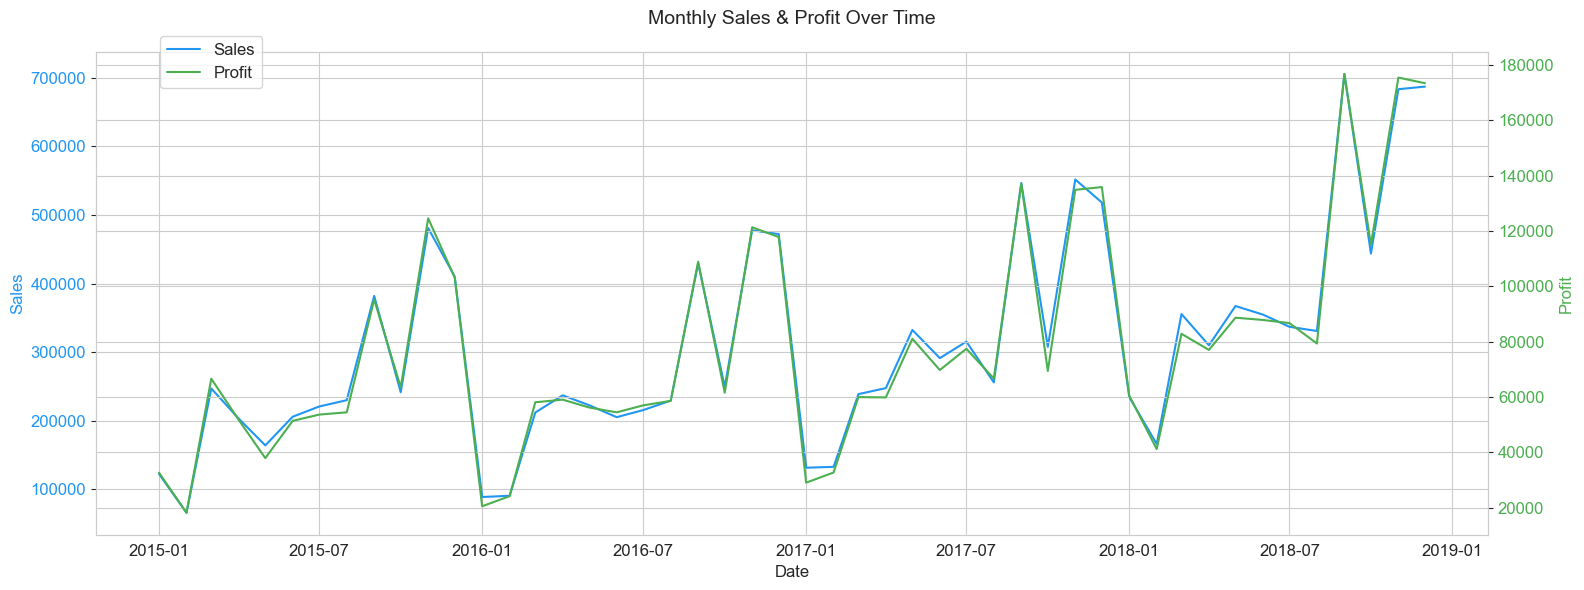

In [37]:
monthly_sales = df.groupby(df['Order Date'].dt.to_period('M')).agg(
    Sales=('Sales', 'sum'),
    Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).reset_index()
monthly_sales['Order Date'] = monthly_sales['Order Date'].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(16, 6))
ax1.plot(monthly_sales['Order Date'], monthly_sales['Sales'], color='#2196F3', linewidth=1.5, label='Sales')
ax1.set_xlabel('Date')
ax1.set_ylabel('Sales', color='#2196F3')
ax1.tick_params(axis='y', labelcolor='#2196F3')

ax2 = ax1.twinx()
ax2.plot(monthly_sales['Order Date'], monthly_sales['Profit'], color='#4CAF50', linewidth=1.5, label='Profit')
ax2.set_ylabel('Profit', color='#4CAF50')
ax2.tick_params(axis='y', labelcolor='#4CAF50')

fig.suptitle('Monthly Sales & Profit Over Time', fontsize=14)
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.95))
plt.tight_layout()
plt.show()

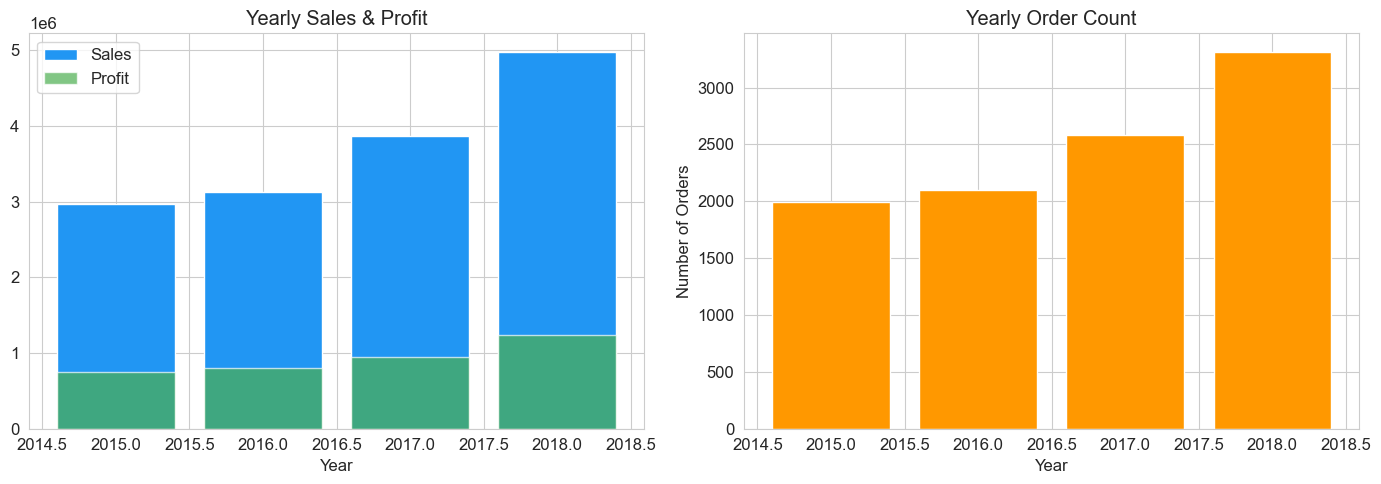

In [38]:
yearly = df.groupby('Year').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Orders=('Order ID', 'count')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(yearly['Year'], yearly['Total_Sales'], color='#2196F3', label='Sales')
axes[0].bar(yearly['Year'], yearly['Total_Profit'], color='#4CAF50', alpha=0.7, label='Profit')
axes[0].set_title('Yearly Sales & Profit')
axes[0].legend()
axes[0].set_xlabel('Year')

axes[1].bar(yearly['Year'], yearly['Orders'], color='#FF9800')
axes[1].set_title('Yearly Order Count')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Number of Orders')

plt.tight_layout()
plt.show()

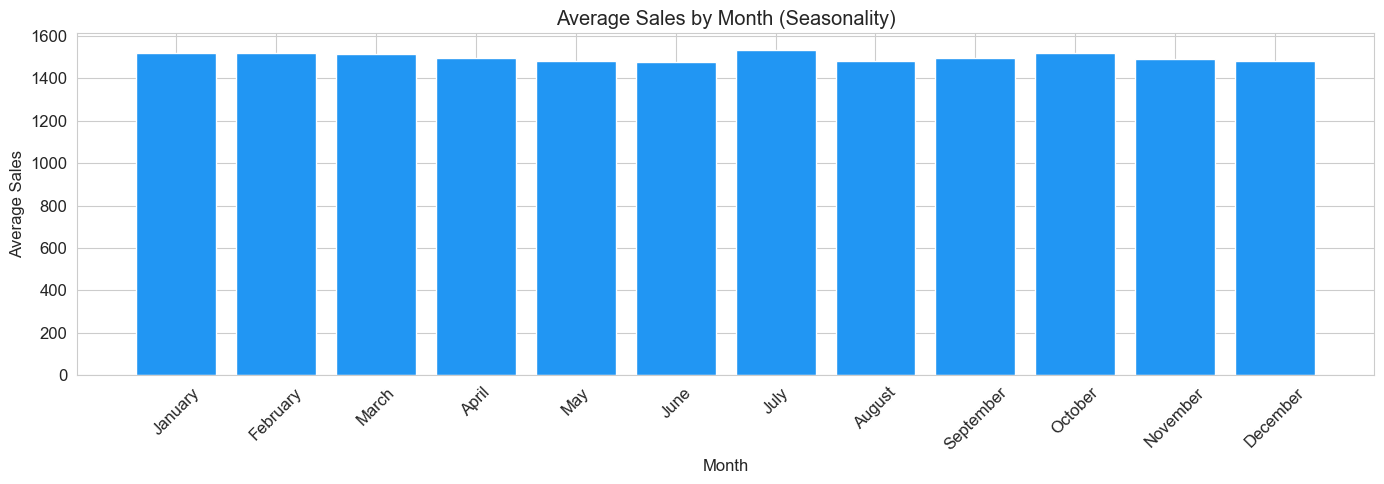

In [39]:
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

monthly_avg = df.groupby('Month_Name')['Sales'].mean().reindex(month_order)

plt.figure(figsize=(14, 5))
plt.bar(monthly_avg.index, monthly_avg.values, color='#2196F3')
plt.title('Average Sales by Month (Seasonality)')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 8. Regional Performance Deep-Dive

In [40]:
region_summary = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Avg_Discount=('Discount', 'mean'),
    Orders=('Order ID', 'count')
).sort_values('Total_Sales', ascending=False)

region_summary['Profit_Margin_%'] = (region_summary['Total_Profit'] / region_summary['Total_Sales'] * 100).round(2)
region_summary

,Total_Sales,Total_Profit,Avg_Discount,Orders,Profit_Margin_%
Region,,,,,
West,4798743,1192004.61,0.224727,3203,24.84
East,4248368,1074345.58,0.227672,2848,25.29
Central,3468156,856806.84,0.228726,2323,24.70
South,2440461,623562.89,0.226776,1619,25.55
North,1254,401.28,0.120000,1,32.00


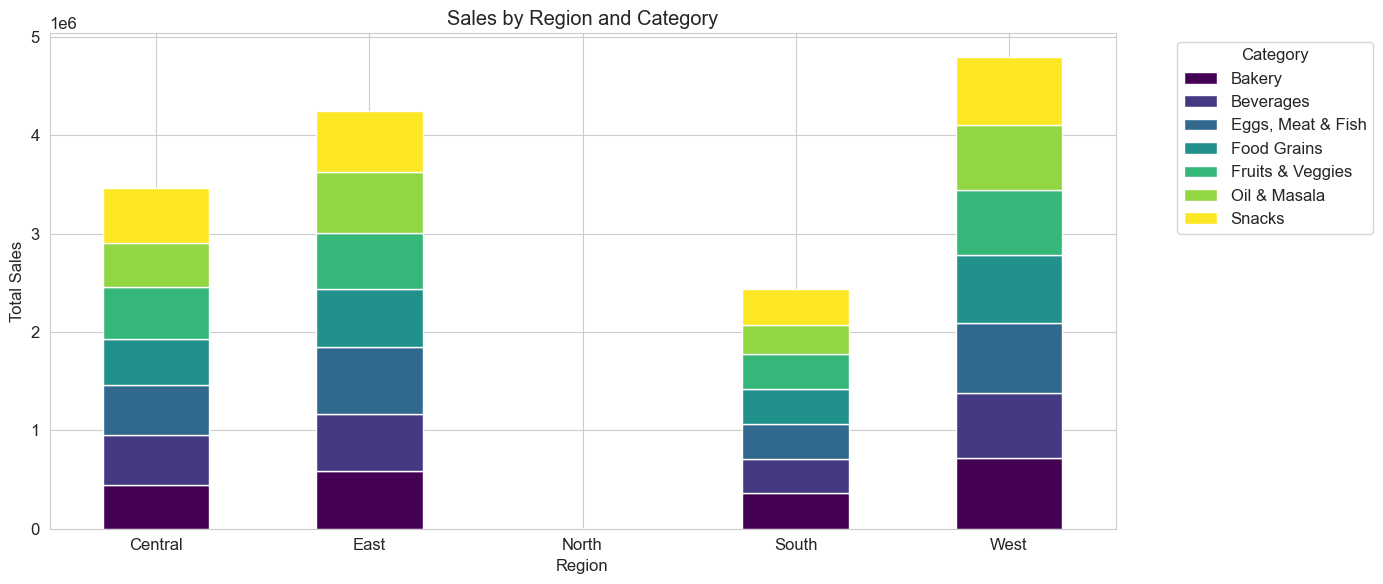

In [41]:
region_cat = df.groupby(['Region', 'Category'])['Sales'].sum().unstack(fill_value=0)

region_cat.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='viridis')
plt.title('Sales by Region and Category')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 9. Top Customers

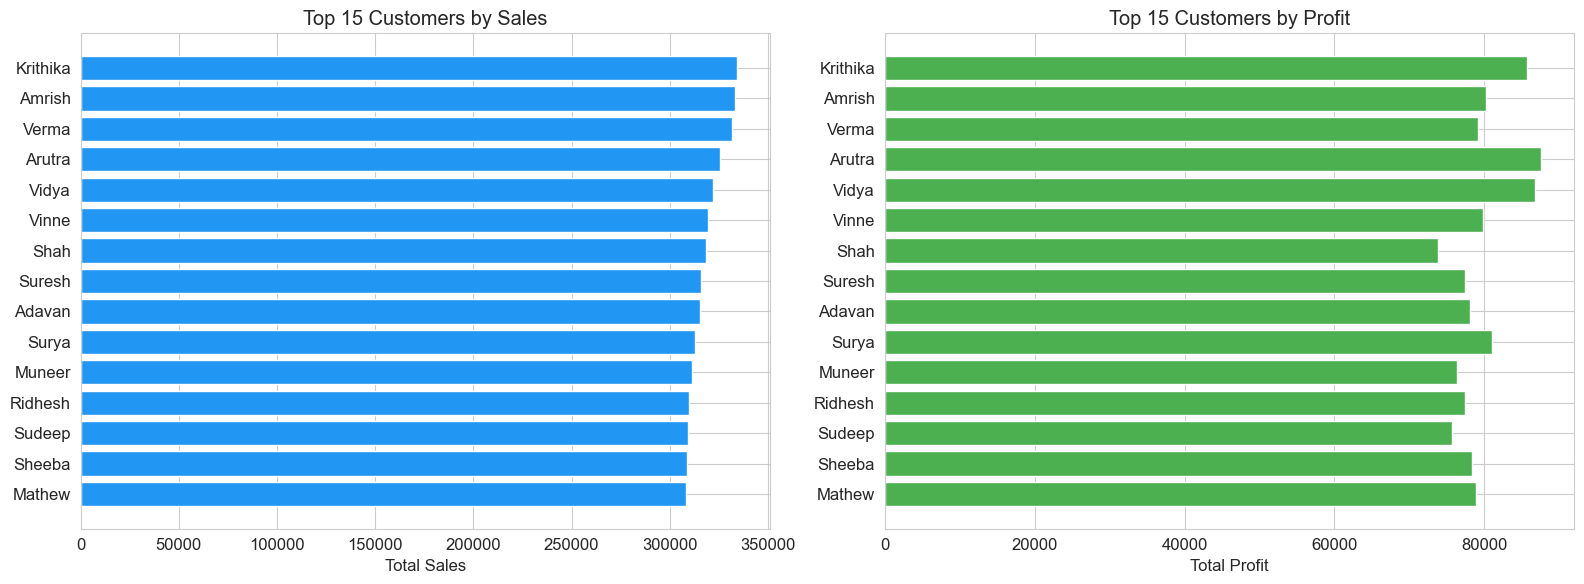

In [42]:
top_customers = df.groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Orders=('Order ID', 'count')
).sort_values('Total_Sales', ascending=False).head(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(top_customers.index[::-1], top_customers['Total_Sales'][::-1], color='#2196F3')
axes[0].set_title('Top 15 Customers by Sales')
axes[0].set_xlabel('Total Sales')

axes[1].barh(top_customers.index[::-1], top_customers['Total_Profit'][::-1], color='#4CAF50')
axes[1].set_title('Top 15 Customers by Profit')
axes[1].set_xlabel('Total Profit')

plt.tight_layout()
plt.show()

## 10. Discount Impact Analysis

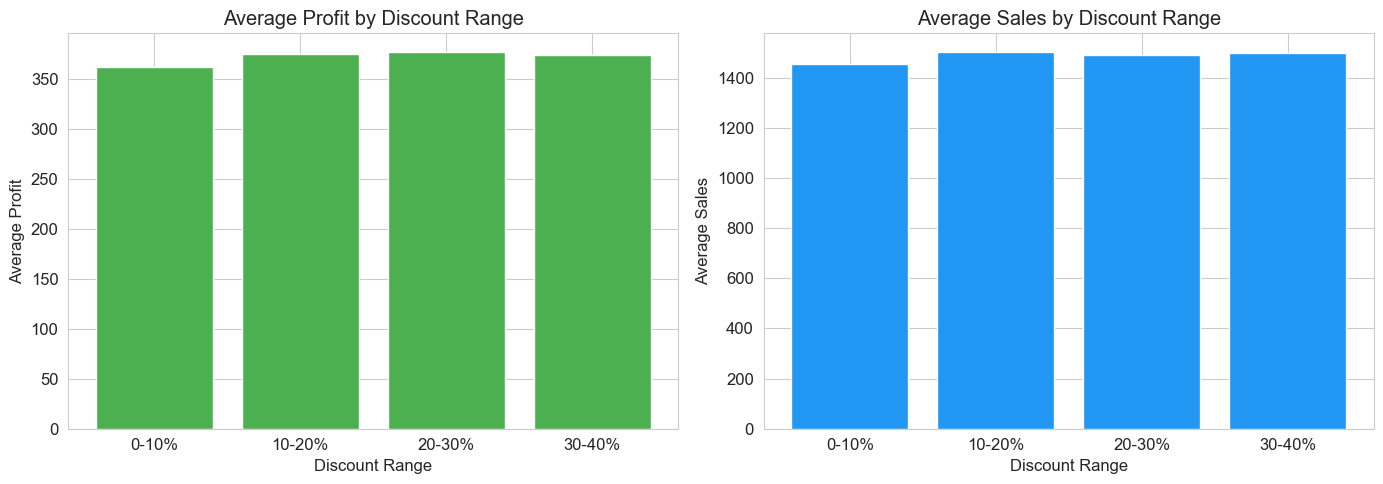

In [43]:
df['Discount_Bin'] = pd.cut(df['Discount'], bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5],
                            labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%'])

discount_analysis = df.groupby('Discount_Bin', observed=True).agg(
    Avg_Profit=('Profit', 'mean'),
    Total_Profit=('Profit', 'sum'),
    Avg_Sales=('Sales', 'mean'),
    Count=('Order ID', 'count')
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(discount_analysis.index.astype(str), discount_analysis['Avg_Profit'], color='#4CAF50')
axes[0].set_title('Average Profit by Discount Range')
axes[0].set_xlabel('Discount Range')
axes[0].set_ylabel('Average Profit')

axes[1].bar(discount_analysis.index.astype(str), discount_analysis['Avg_Sales'], color='#2196F3')
axes[1].set_title('Average Sales by Discount Range')
axes[1].set_xlabel('Discount Range')
axes[1].set_ylabel('Average Sales')

plt.tight_layout()
plt.show()

## 11. Key Findings & Directions for Final Project

After exploring the Supermart Grocery Sales dataset, here are the main observations:

**Dataset Overview:**
- ~9,994 orders across multiple years, cities, and product categories in Tamil Nadu, India
- Key numerical variables: Sales, Discount, Profit
- Key categorical variables: Category, Sub Category, Region, City

**Key Findings:**
1. **Sales & Profit are positively correlated** — higher sales tend to yield higher profit, though with variation
2. **Discount has a nuanced impact** — moderate discounts can boost volume but heavy discounts erode profit margins
3. **Category performance varies** — some categories generate high revenue but lower margins, suggesting different pricing strategies
4. **Regional differences exist** — regions show different sales patterns and profit margins
5. **Seasonality patterns** — sales fluctuate across months, suggesting seasonal demand cycles
6. **Top customers** — a relatively small number of customers contribute disproportionately to total sales

**Possible Directions for the Final Project / Dashboard:**
- Business performance dashboard showing sales, profit, and growth trends
- Category profitability analysis with drill-down into sub-categories
- Regional performance comparison
- Discount optimization — identifying the sweet spot for discounts
- Customer segmentation by value and frequency